# VTS Methods on Multi-Individual Simulated DAGs

This notebook applies **Virtual Typical Subject (VTS)** methods to multi-individual simulated DAG data and evaluates MDM structure learning on the resulting VTS representations.

## Workflow
1. Load multi-individual data from `multi-individual/` (same topology, different seeds)
2. Compute VTS via **mean-based** and **concatenation** methods
3. Fit MDM on each VTS representation
4. Compare learned structures with true DAG
5. Visualize final structures (True vs VTS-Mean vs VTS-Concat)

**Prerequisite:** Generate multi-individual data with:
```python
from simulate_dags import run_simulations
run_simulations(output_dir="multi-individual/", n_individuals=5, w_values=(0.01,), v_values=(100.0,), t_values=(200,))
```

In [1]:
import os
import sys
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, os.path.abspath('../..'))
from mdmp import MDM, compute_vts

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Multi-Individual Data

Load individual CSV files from `multi-individual/` and build 3D arrays (I x T x N).

In [2]:
def load_multi_individual_data(data_dir, dag_prefix, n_individuals=5):
    """Load multi-individual data into 3D array (I x T x N)."""
    arrays = []
    for i in range(1, n_individuals + 1):
        fpath = os.path.join(data_dir, f"{dag_prefix}_ind{i}.csv")
        if not os.path.exists(fpath):
            raise FileNotFoundError(f"Expected {fpath}")
        df = pd.read_csv(fpath)
        arrays.append(df.values)
    return np.array(arrays)

data_dir = "./multi-individual/"
prefix_3var = "dag_3var_W0.01_V100.0_T200"
prefix_5var = "dag_5var_W0.01_V100.0_T200"

# Load 3-variable and 5-variable multi-individual data
aligned_3var = load_multi_individual_data(data_dir, prefix_3var)
aligned_5var = load_multi_individual_data(data_dir, prefix_5var)

print(f"3-var DAG: {aligned_3var.shape} (I x T x N)")
print(f"5-var DAG: {aligned_5var.shape} (I x T x N)")

# Load true adjacency matrices
true_adj_3var = pd.read_csv(
    os.path.join(data_dir, f"{prefix_3var}_true_adjacency.csv"),
    index_col=0
).values.astype(int)

true_adj_5var = pd.read_csv(
    os.path.join(data_dir, f"{prefix_5var}_true_adjacency.csv"),
    index_col=0
).values.astype(int)

print(f"\nTrue 3-var adjacency shape: {true_adj_3var.shape}")
print(f"True 5-var adjacency shape: {true_adj_5var.shape}")

3-var DAG: (5, 200, 3) (I x T x N)
5-var DAG: (5, 200, 5) (I x T x N)

True 3-var adjacency shape: (3, 3)
True 5-var adjacency shape: (5, 5)


## Compute VTS via Mean and Concatenation

### Compare VTS Methods (MSE, Correlation)

Optional: compare mean vs concatenation representation quality.

In [5]:
# Mean-based VTS (subject-level mean, then group mean)
result_mean_3var = compute_vts(aligned_3var, method="mean")
result_mean_5var = compute_vts(aligned_5var, method="mean")

print("Mean-based VTS:")
print(f"  3-var: shape {result_mean_3var.vts_data.shape}")
print(f"  5-var: shape {result_mean_5var.vts_data.shape}")

# Concatenation-based VTS (concatenate along time, return series for MDM)
list_3var = [aligned_3var[i] for i in range(aligned_3var.shape[0])]
list_5var = [aligned_5var[i] for i in range(aligned_5var.shape[0])]

result_concat_3var = compute_vts(list_3var, method="concatenation")
result_concat_5var = compute_vts(list_5var, method="concatenation")

print("\nConcatenation-based VTS:")
print(f"  3-var: shape {result_concat_3var.vts_data.shape}")
print(f"  5-var: shape {result_concat_5var.vts_data.shape}")

Mean-based VTS:
  3-var: shape (200, 3)
  5-var: shape (200, 5)

Concatenation-based VTS:
  3-var: shape (1000, 3)
  5-var: shape (1000, 5)


## Fit MDM on VTS and Compare with True Structure

In [6]:
def compute_metrics(true_adj, estimated_adj):
    """Compute evaluation metrics for DAG structure learning."""
    n_n = true_adj.shape[0]
    pairs = list(combinations(range(n_n), 2))
    m_con_true = np.array([(true_adj[i,j] + true_adj[j,i]) for i, j in pairs])
    m_con_est = np.array([(estimated_adj[i,j] + estimated_adj[j,i]) for i, j in pairs])
    k = np.zeros((n_n, n_n))
    for idx, (i, j) in enumerate(pairs):
        k[i, j] = k[j, i] = 1 if m_con_true[idx] >= 1 else 0
    accuracy = np.mean(m_con_est == m_con_true)
    sensitivity = np.mean(m_con_est[m_con_true == 1] == 1) if np.any(m_con_true == 1) else np.nan
    specificity = np.mean(m_con_est[m_con_true == 0] == 0) if np.any(m_con_true == 0) else np.nan
    ppv = np.mean(m_con_true[m_con_est == 1] == 1) if np.any(m_con_est == 1) else np.nan
    npv = np.mean(m_con_true[m_con_est == 0] == 0) if np.any(m_con_est == 0) else np.nan
    pairs_conn = [(i, j) for i, j in pairs if k[i, j] == 1]
    d_accuracy = np.mean([(true_adj[i,j]==estimated_adj[i,j])&(true_adj[j,i]==estimated_adj[j,i]) for i,j in pairs_conn]) if pairs_conn else np.nan
    return {'accuracy': accuracy, 'sensitivity': sensitivity, 'specificity': specificity, 'ppv': ppv, 'npv': npv, 'directional_accuracy': d_accuracy}

# Fit MDM on mean-based VTS
print("Fitting MDM on mean-based VTS...")
model_mean_3var = MDM(result_mean_3var.vts_data, method="hc", verbose=False)
model_mean_5var = MDM(result_mean_5var.vts_data, method="hc", verbose=False)

# Fit MDM on concatenation VTS
print("Fitting MDM on concatenation VTS...")
model_concat_3var = MDM(result_concat_3var.vts_data, method="hc", verbose=False)
model_concat_5var = MDM(result_concat_5var.vts_data, method="hc", verbose=False)

# Compute metrics
metrics_mean_3var = compute_metrics(true_adj_3var, model_mean_3var.adj_mat)
metrics_mean_5var = compute_metrics(true_adj_5var, model_mean_5var.adj_mat)
metrics_concat_3var = compute_metrics(true_adj_3var, model_concat_3var.adj_mat)
metrics_concat_5var = compute_metrics(true_adj_5var, model_concat_5var.adj_mat)

print("\n--- 3-var DAG ---")
print("VTS-Mean:    accuracy={:.4f}, sensitivity={:.4f}, edges={}".format(metrics_mean_3var['accuracy'], metrics_mean_3var['sensitivity'], int(np.sum(model_mean_3var.adj_mat))))
print("VTS-Concat:  accuracy={:.4f}, sensitivity={:.4f}, edges={}".format(metrics_concat_3var['accuracy'], metrics_concat_3var['sensitivity'], int(np.sum(model_concat_3var.adj_mat))))
print("\n--- 5-var DAG ---")
print("VTS-Mean:    accuracy={:.4f}, sensitivity={:.4f}, edges={}".format(metrics_mean_5var['accuracy'], metrics_mean_5var['sensitivity'], int(np.sum(model_mean_5var.adj_mat))))
print("VTS-Concat:  accuracy={:.4f}, sensitivity={:.4f}, edges={}".format(metrics_concat_5var['accuracy'], metrics_concat_5var['sensitivity'], int(np.sum(model_concat_5var.adj_mat))))

Fitting MDM on mean-based VTS...


  0%|          | 8/1000000 [00:05<195:32:09,  1.42it/s]


Fitting MDM on concatenation VTS...


  0%|          | 5/1000000 [00:16<942:51:31,  3.39s/it] 



--- 3-var DAG ---
VTS-Mean:    accuracy=0.6667, sensitivity=0.5000, edges=1
VTS-Concat:  accuracy=1.0000, sensitivity=1.0000, edges=2

--- 5-var DAG ---
VTS-Mean:    accuracy=0.5000, sensitivity=0.6000, edges=6
VTS-Concat:  accuracy=1.0000, sensitivity=1.0000, edges=5


## Visualize Final Structures

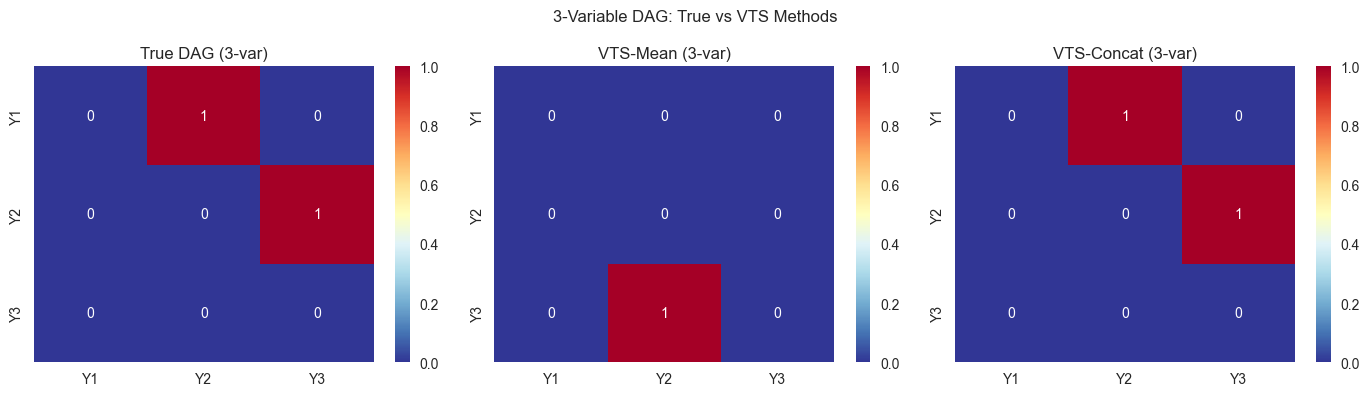

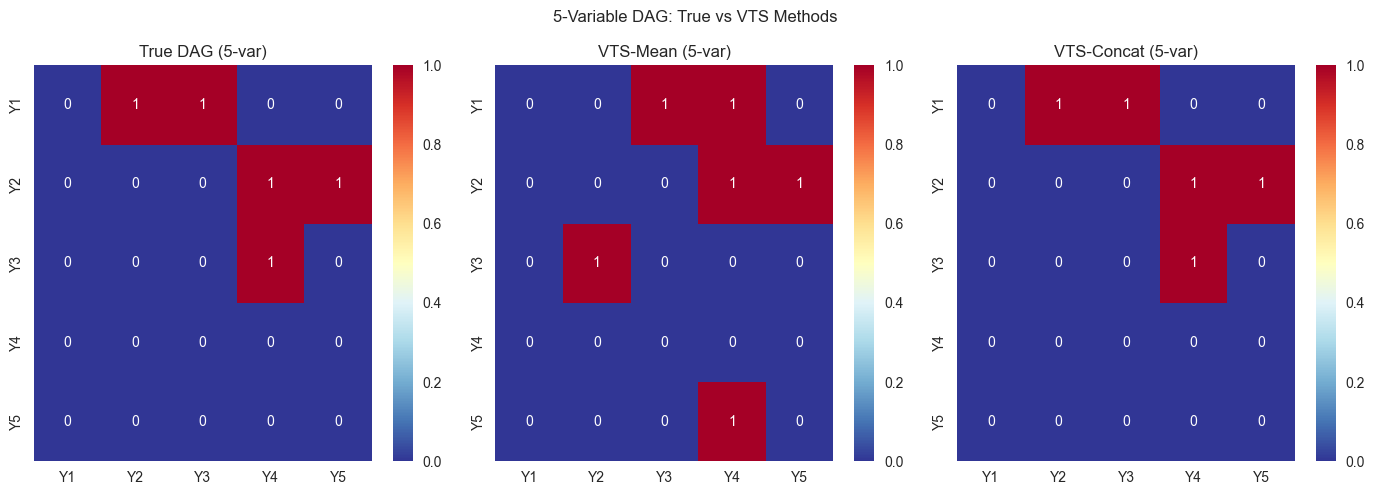

In [7]:
def plot_adj_heatmap(adj_mat, title, ax, node_names=None):
    if node_names is None:
        node_names = [f"Y{i+1}" for i in range(adj_mat.shape[0])]
    sns.heatmap(adj_mat, annot=True, fmt='d', cmap='RdYlBu_r',
                xticklabels=node_names, yticklabels=node_names,
                cbar=True, ax=ax, vmin=0, vmax=1)
    ax.set_title(title)

node_names_3var = ['Y1', 'Y2', 'Y3']
node_names_5var = ['Y1', 'Y2', 'Y3', 'Y4', 'Y5']

# 3-var DAG: True, VTS-Mean, VTS-Concat
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_adj_heatmap(true_adj_3var, 'True DAG (3-var)', axes[0], node_names_3var)
plot_adj_heatmap(model_mean_3var.adj_mat, 'VTS-Mean (3-var)', axes[1], node_names_3var)
plot_adj_heatmap(model_concat_3var.adj_mat, 'VTS-Concat (3-var)', axes[2], node_names_3var)
plt.suptitle('3-Variable DAG: True vs VTS Methods', fontsize=12)
plt.tight_layout()
plt.show()

# 5-var DAG
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
plot_adj_heatmap(true_adj_5var, 'True DAG (5-var)', axes[0], node_names_5var)
plot_adj_heatmap(model_mean_5var.adj_mat, 'VTS-Mean (5-var)', axes[1], node_names_5var)
plot_adj_heatmap(model_concat_5var.adj_mat, 'VTS-Concat (5-var)', axes[2], node_names_5var)
plt.suptitle('5-Variable DAG: True vs VTS Methods', fontsize=12)
plt.tight_layout()
plt.show()

## Summary Table

In [8]:
summary = pd.DataFrame([
    {'DAG': '3-var', 'Method': 'VTS-Mean', 'Accuracy': metrics_mean_3var['accuracy'], 'Sensitivity': metrics_mean_3var['sensitivity'], 'Edges': int(np.sum(model_mean_3var.adj_mat))},
    {'DAG': '3-var', 'Method': 'VTS-Concat', 'Accuracy': metrics_concat_3var['accuracy'], 'Sensitivity': metrics_concat_3var['sensitivity'], 'Edges': int(np.sum(model_concat_3var.adj_mat))},
    {'DAG': '5-var', 'Method': 'VTS-Mean', 'Accuracy': metrics_mean_5var['accuracy'], 'Sensitivity': metrics_mean_5var['sensitivity'], 'Edges': int(np.sum(model_mean_5var.adj_mat))},
    {'DAG': '5-var', 'Method': 'VTS-Concat', 'Accuracy': metrics_concat_5var['accuracy'], 'Sensitivity': metrics_concat_5var['sensitivity'], 'Edges': int(np.sum(model_concat_5var.adj_mat))},
])

print("Summary: VTS methods on multi-individual simulated DAGs")
print(summary.to_string(index=False))

Summary: VTS methods on multi-individual simulated DAGs
  DAG     Method  Accuracy  Sensitivity  Edges
3-var   VTS-Mean  0.666667          0.5      1
3-var VTS-Concat  1.000000          1.0      2
5-var   VTS-Mean  0.500000          0.6      6
5-var VTS-Concat  1.000000          1.0      5
